# Non-Linear Feature Engineering for Logistic Regression
Linear classification models are not suited to non-linearly separable data. Similar to linear regression, feature engineering can make linear models work. This is illustrated with synthetic datasets where each has two original features and two classes.

The first dataset is "moons", because the data points from each class are shaped like a crescent moon.

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

feature_names = ["Feature #0", "Feature #1"]
target_name = "class"

X, y = make_moons(
    n_samples=100,
    noise=0.13,
    random_state=42
)

moons = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name]
)
data_moons, target_moons = moons[feature_names], moons[target_name]

The second dataset is the "Gaussian quantiles" as all points are sampled from a 2D Gaussian (normal) distribution regardless of the class - points closest to the center are class 1, and points in the outer edges are class 0.

In [6]:
from sklearn.datasets import make_gaussian_quantiles

X, y = make_gaussian_quantiles(
    n_samples=100,
    n_features=2,
    n_classes=2,
    random_state=42
)
gauss = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name],
)
data_gauss, target_gauss = gauss[feature_names], gauss[target_name]

The third dataset is the "XOR" as the data points are sampled from a uniform distribution in 2D space and the class is defined by the XOR operation on the two features.

In [7]:
xor = pd.DataFrame(
    np.random.RandomState(0).uniform(low=-1, high=1, size=(200, 2)),
    columns=feature_names,
)
target_xor = np.logical_xor(xor["Feature #0"] > 0, xor["Feature #1"] > 0)
target_xor = target_xor.astype(np.int32)
xor["class"] = target_xor
data_xor = xor[feature_names]

[Text(0.5, 1.0, 'The XOR dataset'), Text(0.5, 0, 'Feature #0')]

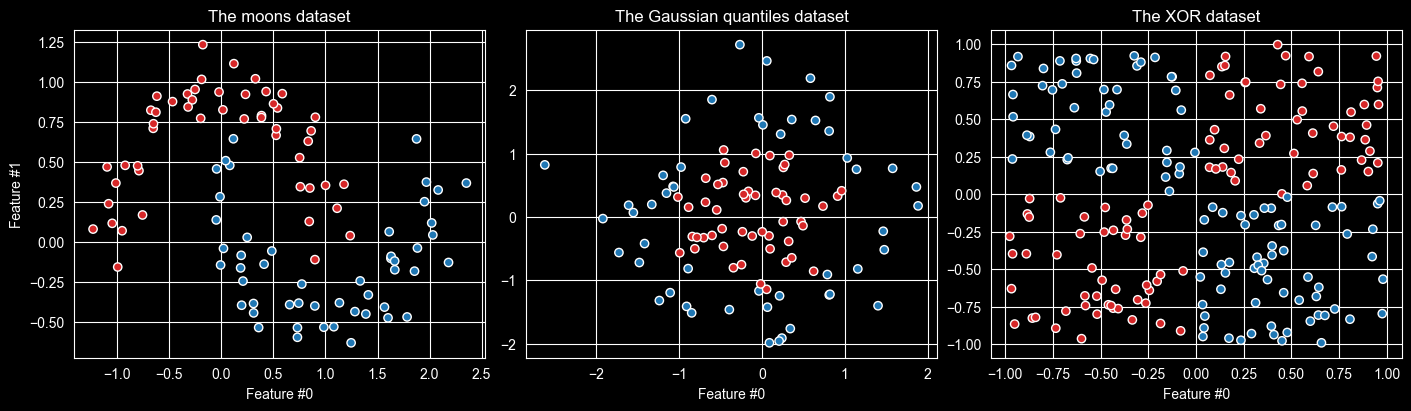

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


_, axs = plt.subplots(ncols=3, figsize=(14, 4), constrained_layout=True)

common_scatter_plot_params = dict(
    cmap=ListedColormap(["tab:red", "tab:blue"]),
    edgecolor="white",
    linewidth=1,
)

axs[0].scatter(
    data_moons[feature_names[0]],
    data_moons[feature_names[1]],
    c=target_moons,
    **common_scatter_plot_params,
)
axs[1].scatter(
    data_gauss[feature_names[0]],
    data_gauss[feature_names[1]],
    c=target_gauss,
    **common_scatter_plot_params,
)
axs[2].scatter(
    data_xor[feature_names[0]],
    data_xor[feature_names[1]],
    c=target_xor,
    **common_scatter_plot_params,
)
axs[0].set(
    title="The moons dataset",
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)
axs[1].set(
    title="The Gaussian quantiles dataset",
    xlabel=feature_names[0],
)
axs[2].set(
    title="The XOR dataset",
    xlabel=feature_names[0],
)

We define a function to help us fit a given model and plot its decision boundary on the previous datasets at a glance.

In [9]:
from sklearn.inspection import DecisionBoundaryDisplay


def plot_decision_boundary(model, title=None):
    datasets = [
        (data_moons, target_moons),
        (data_gauss, target_gauss),
        (data_xor, target_xor),
    ]
    fig, axs = plt.subplots(
        ncols=3,
        figsize=(14, 4),
        constrained_layout=True,
    )

    for i, ax, (data, target) in zip(
        range(len(datasets)),
        axs,
        datasets,
    ):
        model.fit(data, target)
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="pcolormesh",
            cmap="RdBu",
            alpha=0.8,
            # Setting vmin and vmax to the extreme values of the probability to
            # ensure that 0.5 is mapped to white (the middle) of the blue-red
            # colormap.
            vmin=0,
            vmax=1,
            ax=ax,
        )
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="contour",
            alpha=0.8,
            levels=[0.5],  # 0.5 probability contour line
            linestyles="--",
            linewidths=2,
            ax=ax,
        )
        ax.scatter(
            data[feature_names[0]],
            data[feature_names[1]],
            c=target,
            **common_scatter_plot_params,
        )
        if i > 0:
            ax.set_ylabel(None)
    if title is not None:
        fig.suptitle(title)

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_regression = make_pipeline(StandardScaler(), LogisticRegression())

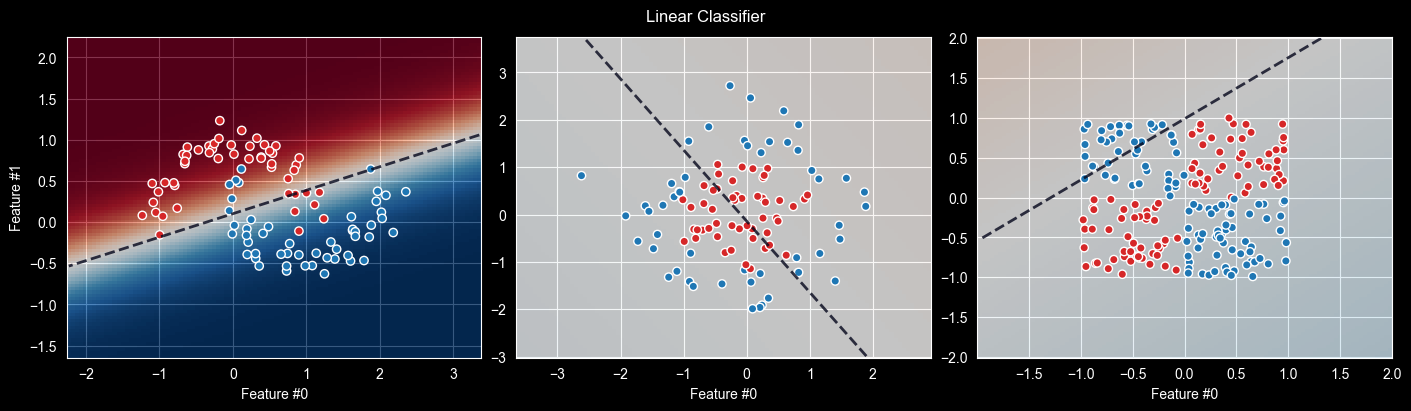

In [11]:
plot_decision_boundary(logistic_regression, title="Linear Classifier")

This confirms it is not possible to separate the two classes with a linear model. So, we will engineer non-linear features. We can do this with techniques like:
- Binning
- Splines
- Polynomial features
- Kernel approximation

We start with the binning transformation.

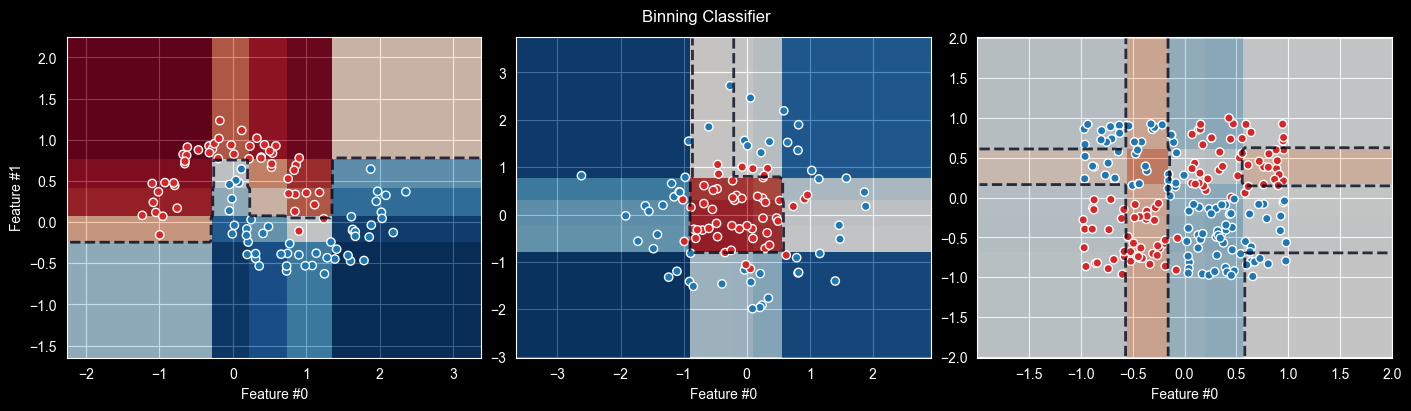

In [17]:
from sklearn.preprocessing import KBinsDiscretizer

classifier = make_pipeline(
    KBinsDiscretizer(n_bins=5, encode="onehot", quantile_method='averaged_inverted_cdf'),
    LogisticRegression()
)

plot_decision_boundary(classifier, title="Binning Classifier")

This classifier is constrained to follow *axis-aligned segments*, similar to what a decision tree would do. However, this does not solve the XOR dataset as the binning transformation is a *feature-wise transformation*, meaning it cannot capture interactions *between* features necessary to separate the XOR set.

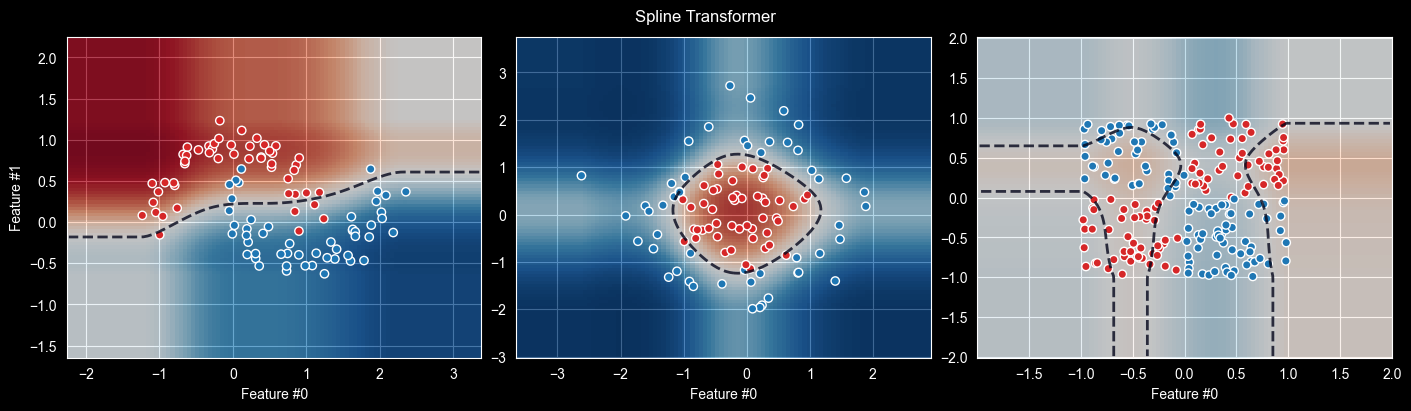

In [18]:
from sklearn.preprocessing import SplineTransformer

classifier = make_pipeline(
    SplineTransformer(degree=3, n_knots=5),
    LogisticRegression()
)

plot_decision_boundary(classifier, title="Spline Transformer")

The spline transformation makes the decision boundary smooth, and while it favours axis-aligned decision rules when extrapolation in low-density regions, it can adopt a curvy decision boundary in high-density regions. It is still a *feature-wise transformation*, making it useless on the XOR set.

## Modeling Non-Additive Feature Interactions
We now consider feature engineering techniques that non-linearly combine the original features to capture the interactions between them.

First, we consider polynomial features.

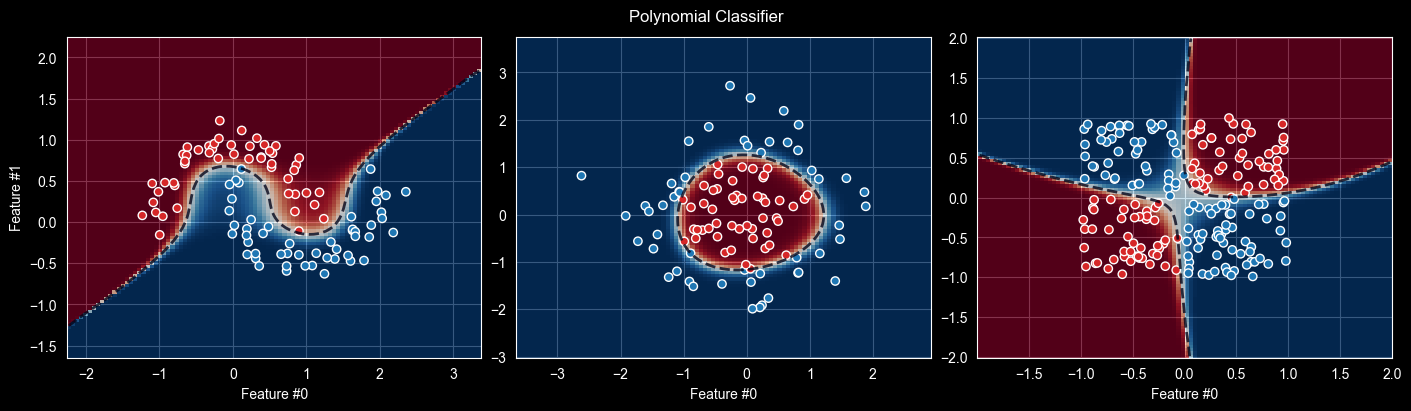

In [19]:
from sklearn.preprocessing import PolynomialFeatures

classifier = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3, include_bias=False),
    LogisticRegression(C=10)
)

plot_decision_boundary(classifier, title="Polynomial Classifier")

The polynomial classifier is smooth and can successfully separate all three datasets. We can obtain similar results with a kernel approximation technique.

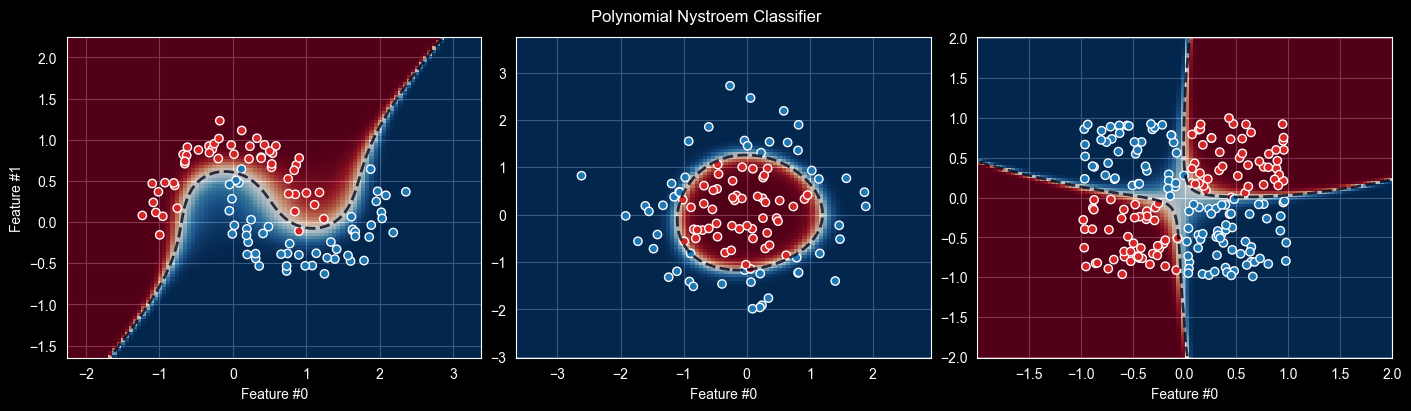

In [21]:
from sklearn.kernel_approximation import Nystroem

classifier = make_pipeline(
    StandardScaler(),
    Nystroem(kernel="poly", degree=3, coef0=1, n_components=100),
    LogisticRegression(C=10),
)

plot_decision_boundary(classifier, title="Polynomial Nystroem Classifier")

## Multi-Step Feature Engineering
It is possible to combine several feature engineering transformers in a single pipeline to blend their resective inductive biases.

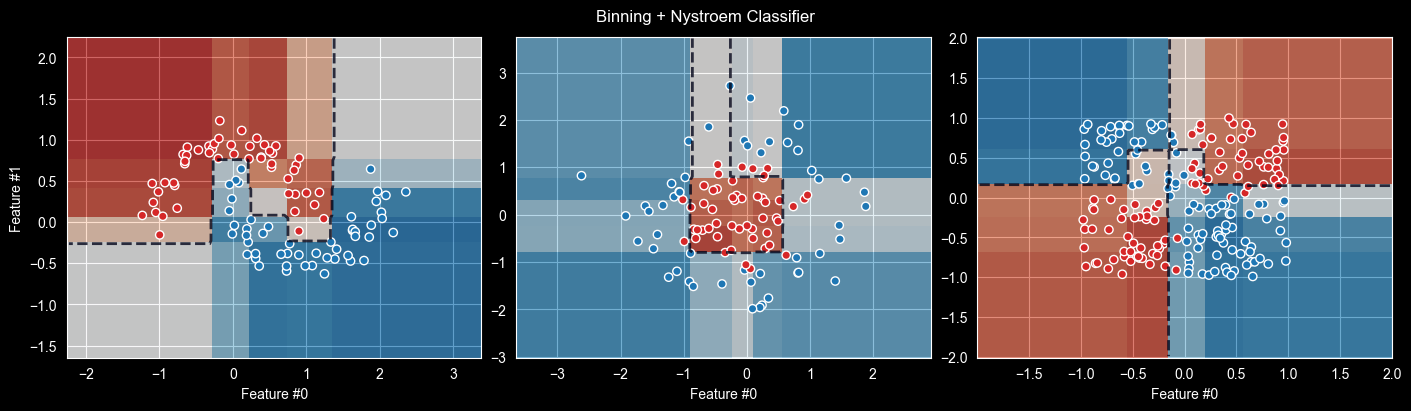

In [24]:
classifier = make_pipeline(
    KBinsDiscretizer(n_bins=5, quantile_method='averaged_inverted_cdf'),
    Nystroem(kernel="rbf", gamma=1.0, n_components=100),
    LogisticRegression(),
)

plot_decision_boundary(classifier, title="Binning + Nystroem Classifier")

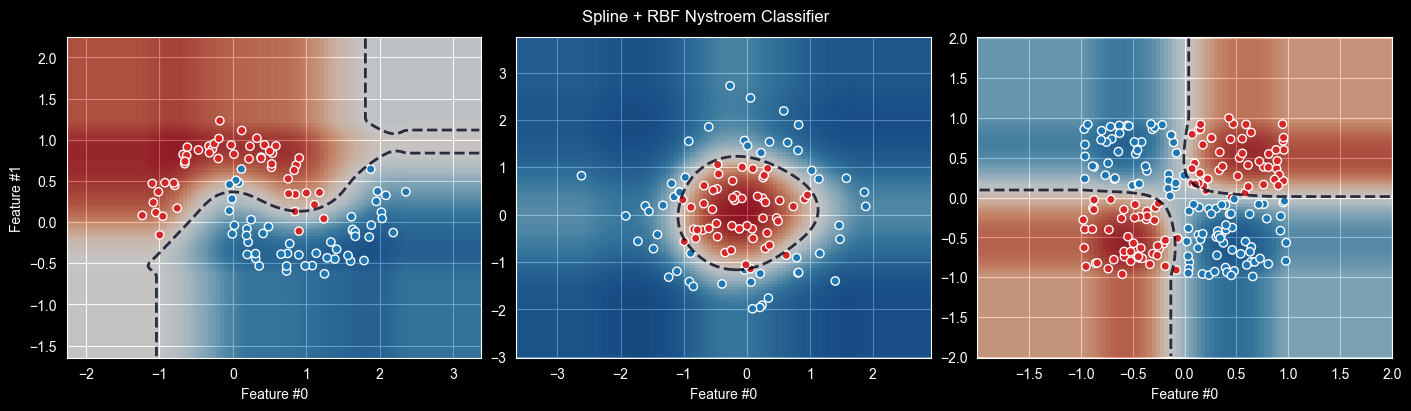

In [26]:
classifier = make_pipeline(
    SplineTransformer(n_knots=5),
    Nystroem(kernel="rbf", gamma=1.0, n_components=100),
    LogisticRegression(),
)

plot_decision_boundary(classifier, title="Spline + RBF Nystroem Classifier")